# CH17A Predicting Firm Fast Growth

Using the bisnode-firms dataset

In [1]:
import os
import sys
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import patsy
import sklearn.metrics as metrics
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    confusion_matrix,
    mean_squared_error,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.tools.eval_measures import rmse

warnings.filterwarnings("ignore")

In [2]:
# Current script folder
path = os.getcwd()

# Set the location of data directory
data_in = os.path.join("..", "data")
data_out = os.path.join("..", "data")
graph_out = os.path.join("..", "graphs")

## Import data

In [3]:
# !!! make sure you have run ch17-firm-fast-growth-data-prep.ipynb before
data = pd.read_csv(os.path.join(data_out, "bisnode_firms_clean.csv"))

In [4]:
data.describe()

,year,comp_id,amort,curr_assets,curr_liab,extra_exp,extra_inc,extra_profit_loss,fixed_assets,inc_bef_tax,...,share_eq_bs_quad,asset_tangibility,liquidity_ratio,roa,labor_intensity,leverage,ln_total_assets,young_high_roa,d1_sales_mil_log_mod,sales_mil_log_sq
count,19996.0,1.999600e+04,1.995800e+04,1.999600e+04,1.999600e+04,1.999600e+04,1.999600e+04,1.999600e+04,1.999600e+04,1.999600e+04,...,19996.000000,19996.000000,19647.000000,19996.000000,19958.000000,19996.000000,19996.000000,19996.000000,19996.000000,1.999600e+04
mean,2012.0,1.535275e+11,9.613279e+03,1.055301e+05,9.020418e+04,1.304783e+03,2.512944e+03,1.204834e+03,1.585579e+05,7.234908e+03,...,0.479465,0.335533,2.327006,-0.156458,0.299289,0.658384,10.246006,0.089518,-0.049770,1.221355e+01
std,0.0,1.379137e+11,5.091653e+04,4.771275e+05,5.282025e+05,1.207577e+05,1.251575e+05,3.193274e+04,1.204779e+06,1.290689e+05,...,0.389209,0.340594,2.962580,0.456299,0.245390,0.351076,2.076218,0.285497,0.673950,1.047088e+01
min,2012.0,1.001541e+06,-1.489630e+04,0.000000e+00,-8.759259e+03,-1.418519e+03,-1.740741e+02,-2.888889e+05,0.000000e+00,-1.091879e+07,...,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,1.309333,0.000000,-3.000000,2.074996e-07
25%,2012.0,2.906338e+10,1.481481e+02,3.574074e+03,3.554630e+03,0.000000e+00,0.000000e+00,0.000000e+00,2.333333e+02,-5.762963e+03,...,0.086440,0.008395,0.340705,-0.349432,0.125657,0.339740,8.893598,0.000000,-0.154528,4.002632e+00
50%,2012.0,1.141679e+11,9.666667e+02,1.202222e+04,1.416852e+04,0.000000e+00,0.000000e+00,0.000000e+00,5.150000e+03,3.259259e+02,...,0.413706,0.213921,1.113087,0.002807,0.250465,0.765821,10.173515,0.000000,0.000000,9.625974e+00
75%,2012.0,2.581020e+11,4.214815e+03,4.143796e+04,4.769074e+04,0.000000e+00,0.000000e+00,0.000000e+00,4.241018e+04,4.340741e+03,...,0.943454,0.625892,2.779364,0.068201,0.408589,1.000000,11.538431,0.000000,0.112185,1.744029e+01
max,2012.0,4.641050e+11,3.570863e+06,2.066350e+07,4.186429e+07,1.704172e+07,1.709232e+07,3.253704e+06,1.036673e+08,4.378226e+06,...,1.000000,1.000000,10.000000,1.000000,1.000000,1.000000,18.466450,1.000000,3.000000,4.771708e+01


In [5]:
# Quick data overview
print(f"Dataset shape: {data.shape}")
print(f"\nFast growth distribution:")
print(data['fast_growth'].value_counts(dropna=False))
print(f"\nFast growth rate: {data['fast_growth'].mean():.2%}")

Dataset shape: (19996, 118)

Fast growth distribution:
fast_growth
0.0    14226
1.0     5770
Name: count, dtype: int64

Fast growth rate: 28.86%


## Define helper functions

In [6]:
def regression_results(y_true, y_pred):

    # Regression metrics
    explained_variance = metrics.explained_variance_score(y_true, y_pred)
    mean_absolute_error = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    median_absolute_error = metrics.median_absolute_error(y_true, y_pred)
    r2 = metrics.r2_score(y_true, y_pred)

    print("explained_variance: ", round(explained_variance, 4))
    print("r2: ", round(r2, 4))
    print("MAE: ", round(mean_absolute_error, 4))
    print("MSE: ", round(mse, 4))
    print("RMSE: ", round(np.sqrt(mse), 4))


def coef_matrix(X, model):

    coef_matrix = pd.concat(
        [pd.DataFrame(X.columns), pd.DataFrame(np.transpose(model.coef_))], axis=1
    )
    coef_matrix.columns = ["variable", "coefficient"]
    # Fix: replaced deprecated DataFrame.append() with pd.concat()
    coef_matrix = pd.concat(
        [coef_matrix, pd.DataFrame([{"variable": "Intercept", "coefficient": model.intercept_}])],
        ignore_index=True,
    )
    return coef_matrix


def cv_fast_growth(lambdas, C_values, model):
    d = {
        "lambdas": lambdas,
        "C_values": C_values,
        "mean_cv_score": model.scores_[1].mean(axis=0),
    }
    return pd.DataFrame(data=d)


def sigmoid_array(x):
    return 1 / (1 + np.exp(-x))


def generate_fold_prediction(model, X, fold, param_index):
    fold_coef = model.coefs_paths_[1][fold, param_index, :]
    return sigmoid_array(
        np.dot(X, np.transpose(fold_coef)[:-1]) + np.transpose(fold_coef)[-1]
    )


def create_loss_plot(all_coords, optimal_threshold, curr_exp_loss):
    all_coords_copy = all_coords.copy()
    all_coords_copy["loss"] = (
        all_coords_copy.false_pos * FP + all_coords_copy.false_neg * FN
    ) / all_coords_copy.n

    t = optimal_threshold
    l = curr_exp_loss

    # Plot loss curve
    sns.lineplot(x=all_coords_copy["thresholds"], y=all_coords_copy["loss"])

    # Vertical line for optimal threshold
    plt.axvline(x=t, linestyle="--")

    # Annotations
    plt.text(
        t - 0.03,
        all_coords_copy["loss"].max() - 0.7,
        f"Best threshold: {round(t, 2)}",
        color="red",
        rotation=90,
        fontsize=8,
    )
    plt.text(t + 0.06, l, f"{round(l, 2)}", fontsize=8)

    # Labels and limits
    plt.xlabel("Thresholds")
    plt.ylabel("Expected loss")
    plt.xlim(-0.01, 1.01)
    plt.xticks(np.arange(0, 1.1, 0.1))

    # Style
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig(os.path.join(graph_out, "loss_plot.png"), bbox_inches='tight', dpi=300)
    plt.show()


def create_roc_plot(y_true, y_pred, title='ROC Curve'):
    """
    Create ROC curve plot to visualize model discrimination ability.
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)

    # Plot ROC curve
    sns.lineplot(x=fpr, y=tpr, linewidth=1)

    # Fill area under curve
    plt.fill_between(fpr, tpr, alpha=0.3, color="mediumaquamarine")

    # Diagonal reference line
    plt.plot([0, 1], [0, 1], linestyle="dotted", color="black", linewidth=0.9)

    # Labels and limits
    plt.xlabel("False Positive Rate (1-Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xticks(np.arange(0, 1.1, 0.1))
    plt.yticks(np.arange(0, 1.1, 0.1))

    # Style
    sns.despine()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig(os.path.join(graph_out, "roc_plot.png"), bbox_inches='tight', dpi=300)
    plt.show()


def create_roc_plot_with_optimal(all_coords, optimal_threshold):
    all_coords_copy = all_coords.copy()
    all_coords_copy["sp"] = 1 - all_coords_copy.true_neg / all_coords_copy.neg
    all_coords_copy["se"] = all_coords_copy.true_pos / all_coords_copy.pos

    best_coords = all_coords_copy[all_coords_copy.thresholds == optimal_threshold]
    sp = best_coords.sp.values[0]
    se = best_coords.se.values[0]

    # Plot ROC curve
    sns.lineplot(x=all_coords_copy["sp"], y=all_coords_copy["se"])

    # Highlight optimal threshold point
    plt.scatter(sp, se, color="black", s=10)
    plt.text(sp, se + 0.03, f"{round(sp, 2)}, {round(se, 2)}", fontsize=10, ha="center")

    # Fill area under curve
    plt.fill_between(
        all_coords_copy["sp"],
        all_coords_copy["se"],
        alpha=0.3,
        color="mediumaquamarine",
    )

    # Diagonal reference line
    plt.plot([0, 1], [0, 1], linestyle="dotted", color="black", linewidth=0.9)

    # Labels and limits
    plt.xlabel("False Positive Rate (1-Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.xlim(0, 1.01)
    plt.ylim(0, 1.01)
    plt.xticks(np.arange(0, 1.1, 0.1))
    plt.yticks(np.arange(0, 1.1, 0.1))

    # Style
    sns.despine()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.savefig(os.path.join(graph_out, "roc_plot_with_optimal.png"), bbox_inches='tight', dpi=300)
    plt.show()


def create_calibration_plot(data, prob_var, actual_var, y_lab="Actual event probability", n_bins=10, breaks=None):
    # Extract actual values and predicted probabilities, dropping any NaNs
    valid_data = data[[actual_var, prob_var]].dropna()
    y_true = valid_data[actual_var]
    y_prob = valid_data[prob_var]

    # Compute calibration points using sklearn
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='uniform')

    # Plotting
    plt.figure(figsize=(10, 6))

    # Draw diagonal line (perfect calibration)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')

    # Draw the model's calibration curve
    plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')

    plt.xlabel('Predicted event probability')
    plt.ylabel(y_lab)
    plt.title('Calibration Plot')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.savefig(os.path.join(graph_out, "calibration_plot.png"), bbox_inches='tight', dpi=300)
    plt.show()


## Model building

### Define variable sets

Main firm variables

In [7]:
# Main firm variables
rawvars = [
    "curr_assets", "curr_liab", "extra_exp", "extra_inc", "extra_profit_loss",
    "fixed_assets", "inc_bef_tax", "intang_assets", "inventories", "liq_assets",
    "material_exp", "personnel_exp", "profit_loss_year", "sales", "share_eq", "subscribed_cap"
]

Further financial variables

In [8]:
qualityvars = ["balsheet_notfullyear"]
engvar = [
    "liq_assets_bs",
    "curr_assets_bs",
    "subscribed_cap_bs",
    "intang_assets_bs",     
    "extra_exp_pl",
    "extra_inc_pl",
    "extra_profit_loss_pl",
    "inc_bef_tax_pl",
    "inventories_pl",
    "material_exp_pl",
    "profit_loss_year_pl",
    "personnel_exp_pl",
]
engvar2 = [
    "extra_profit_loss_pl_quad",
    "inc_bef_tax_pl_quad",
    "profit_loss_year_pl_quad"
]
engvar3 = [
    "extra_exp_pl_flag_high", "extra_exp_pl_flag_error",
    "extra_inc_pl_flag_high", "extra_inc_pl_flag_error",
    "inventories_pl_flag_high", "inventories_pl_flag_error",
    "material_exp_pl_flag_high", "material_exp_pl_flag_error",
    "personnel_exp_pl_flag_high", "personnel_exp_pl_flag_error",
    "curr_liab_bs_flag_high", "curr_liab_bs_flag_error",
    "liq_assets_bs_flag_high", "liq_assets_bs_flag_error",
    "subscribed_cap_bs_flag_high", "subscribed_cap_bs_flag_error",
    "extra_profit_loss_pl_flag_low", "extra_profit_loss_pl_flag_high", "extra_profit_loss_pl_flag_zero",
    "inc_bef_tax_pl_flag_low", "inc_bef_tax_pl_flag_high", "inc_bef_tax_pl_flag_zero",
    "profit_loss_year_pl_flag_low", "profit_loss_year_pl_flag_high", "profit_loss_year_pl_flag_zero",
    "share_eq_bs_flag_low", "share_eq_bs_flag_high", "share_eq_bs_flag_zero"
]

Growth variables

In [9]:
d1 = [
    "d1_sales_mil_log_mod",
]

Human capital related variables

In [10]:
hr = [
    "gender_m",
    "foreign_management",
    "age",
    "age2",
    "new",
    "ind2_cat",
    "m_region_loc", 
]

Growth Features

In [11]:
growth_features = [
    "asset_tangibility",
    "liquidity_ratio",
    "roa",
    "leverage",
    "ln_total_assets",
    "young_high_roa" 
]

#### Interactions for logit, LASSO

In [12]:
interactions1 = [
    "C(ind2_cat)*age",
    "C(ind2_cat)*age2",
    "C(ind2_cat)*d1_sales_mil_log_mod",
    "C(ind2_cat)*sales_mil_log",
    "C(ind2_cat)*foreign_management",
    "C(ind2_cat)*gender_m",   
]

interactions2 = [
    "sales_mil_log*age",
    "sales_mil_log*gender_m",
    "sales_mil_log*profit_loss_year_pl",
    "sales_mil_log*foreign_management",
]

## Model Setups

We test 5 simple logit regression models with increasing complexity:

- **M1 (Baseline):** Size + Growth + Profitability only (3 variables)
- **M2 (+ Firm Info):** M1 + Balance sheet ratios + Age + Ownership (8 variables)  
- **M3 (+ Financial):** M2 + All financial ratios + Growth features (~30 variables)
- **M4 (+ Flags + HR):** M3 + Flag variables + Quadratics + CEO/labor info (~80 variables)
- **M5 (+ Interactions):** M4 + Industry interactions + Size interactions (~150 variables)

Then we test the following two models:

**LASSO:** Same variables as M5, but with L1 regularization for automatic feature selection

**Random Forest:** Uses raw variables (not engineered ratios) because trees can find non-linearities automatically

1. Simple logit models

In [13]:
M1 = [
    "sales_mil_log",
    "d1_sales_mil_log_mod",
    "profit_loss_year_pl"
]
M2 = [
    "sales_mil_log",
    "d1_sales_mil_log_mod",
    "profit_loss_year_pl",
    "fixed_assets_bs",
    "curr_liab_bs",
    "curr_liab_bs_flag_error",
    "age",
    "foreign_management"
]
M3 = ["sales_mil_log"] + engvar + d1 + hr + growth_features
M4 = (
    ["sales_mil_log"]
    + engvar
    + engvar2
    + engvar3
    + d1
    + hr
    + growth_features
    + qualityvars
)
M5 = (
    M4
    + interactions1
    + interactions2
)

2. Logit + LASSO

In [14]:
logit_lasso_vars = (
    ["sales_mil_log", "sales_mil_log_sq"]
    + engvar
    + engvar2
    + engvar3
    + d1
    + hr               # including firm features like age, ind2_cat, region 
    + growth_features  # including growth features like roa, liquidity_ratio
    + qualityvars
    + interactions1
    + interactions2
)

3. CART and RF (no interactions, no modified features)

In [15]:
rfvars = ["sales_mil", "d1_sales_mil_log_mod"] + rawvars + hr + growth_features + qualityvars

---
# PART I: Probability Prediction

We build three models to predict the probability of fast growth:
1. **Logit Model** (5 specifications: M1–M5)
2. **LASSO Logit** 
3. **Random Forest** 

We evaluate each using 5-fold cross-validation and compare performance using RMSE and computational time.

## 0. Separate train and holdout data

In [16]:
# Remove observations with missing fast_growth (our target variable)
data = data[data['fast_growth'].notna()].copy()
print(f"Modeling dataset: {data.shape[0]} observations")

# Create train-test split (80-20)
data_train, data_holdout = train_test_split(data, train_size=0.8, random_state=42)

Modeling dataset: 19996 observations


In [17]:
print("Total")
print(data["fast_growth"].value_counts(normalize=True))
print("Train")
print(data_train["fast_growth"].value_counts(normalize=True))
print("Holdout")
print(data_holdout["fast_growth"].value_counts(normalize=True))

Total
fast_growth
0.0    0.711442
1.0    0.288558
Name: proportion, dtype: float64
Train
fast_growth
0.0    0.710803
1.0    0.289197
Name: proportion, dtype: float64
Holdout
fast_growth
0.0    0.714
1.0    0.286
Name: proportion, dtype: float64


In [18]:
# Filter variable lists to only include columns present in the data
available_cols = data_train.columns.tolist()

def filter_vars(var_list):
    return [v for v in var_list if v in available_cols or v.startswith("C(")]

engvar3 = filter_vars(engvar3)

# Rebuild M4 and M5 with filtered vars
M4 = (
    ["sales_mil_log"]
    + filter_vars(engvar)
    + filter_vars(engvar2)
    + engvar3
    + filter_vars(d1)
    + filter_vars(hr)
    + filter_vars(growth_features)
    + filter_vars(qualityvars)
)
M5 = M4 + interactions1 + interactions2

logit_lasso_vars = (
    filter_vars(["sales_mil_log", "sales_mil_log_sq"])
    + filter_vars(engvar)
    + filter_vars(engvar2)
    + engvar3
    + filter_vars(d1)
    + filter_vars(hr)
    + filter_vars(growth_features)
    + filter_vars(qualityvars)
    + interactions1
    + interactions2
)

rfvars = filter_vars(["sales_mil", "d1_sales_mil_log_mod"] + rawvars + hr + growth_features + qualityvars)

logit_model_vars = [M1, M2, M3, M4, M5]

print(f"Columns removed: {set(engvar3) - set(filter_vars(engvar3)) if engvar3 != filter_vars(engvar3) else 'none'}")

Columns removed: none


## 1. Predict probabilities with logit and LASSO with CV

Specify 5-fold cross-validation method

In [19]:
k = KFold(n_splits=5, shuffle=True, random_state=42)

### a) Cross-validate logit models

In [20]:
# Set up X-vars
logit_model_vars = [M1, M2, M3, M4, M5]

# Set up Logit model object
# No regularisation needed so setting the paremeter to very high value
C_value_logit = [1e20]

In [21]:
logit_models = dict()
CV_RMSE_folds = dict()

# Track training time
start_time = time.time()

for i, model_vars in enumerate(logit_model_vars):

    model_equation = "fast_growth~" + "+".join(model_vars)
    y_train, X_train = patsy.dmatrices(model_equation, data_train)

    LRCV_brier = LogisticRegressionCV(
        Cs=C_value_logit,
        cv=k,
        refit=True,
        scoring="neg_brier_score",
        solver="newton-cg",
        tol=1e-7,
        random_state=42,
    )

    logit_models["M" + str(i + 1)] = LRCV_brier.fit(X_train, y_train)

    # Calculate RMSE on test for each fold
    CV_RMSE_folds["M" + str(i + 1)] = np.sqrt(
        -1 * logit_models["M" + str(i + 1)].scores_[1].ravel()
    )

logit_time = time.time() - start_time

In [22]:
pd.DataFrame(CV_RMSE_folds)


,M1,M2,M3,M4,M5
0,0.457426,0.434735,0.421858,0.420875,0.419601
1,0.447387,0.440091,0.424834,0.424472,0.426997
2,0.450615,0.436870,0.420574,0.421154,0.422921
3,0.454907,0.436636,0.427116,0.428222,0.429254
4,0.448035,0.431464,0.431920,0.431094,0.433281


In [23]:

print(f"Training time: {logit_time:.2f} seconds")

Training time: 416.53 seconds


### b) Logit + LASSO

In [24]:
model_equation = "fast_growth~" + "+".join(logit_lasso_vars)
y_train, X_train = patsy.dmatrices(model_equation, data_train)

Normalise X vars for LASSO

In [25]:
normalized_logitvars = pd.DataFrame(
    StandardScaler().fit_transform(X_train),
    columns=X_train.design_info.column_names,
)

Set regularization parameters

In [26]:
lambdas = list(10 ** np.arange(-1, -4.01, -1 / 3))
n_obs = normalized_logitvars.shape[0] * 4 / 5
C_values = [
    1 / (l * n_obs) for l in lambdas
]  # Cs are the inverse of regularization strength

Initialize and fit Logit LASSO

In [27]:
start_time = time.time()

logLasso_brier = LogisticRegressionCV(
    Cs=C_values,
    penalty="l1",
    cv=k,
    refit=True,
    scoring="neg_brier_score",
    solver="liblinear",
    random_state=42,
)

logit_models["LASSO"] = logLasso_brier.fit(normalized_logitvars, y_train)
lasso_time = time.time() - start_time

See CV-fold RMSE-s (negative brier score)

In [28]:
cv_fast_growth_lasso = cv_fast_growth(lambdas, C_values, logit_models["LASSO"])
cv_fast_growth_lasso["mean_cv_score"] = np.sqrt(cv_fast_growth_lasso["mean_cv_score"] * -1)
cv_fast_growth_lasso

,lambdas,C_values,mean_cv_score
0,0.100000,0.000875,0.463473
1,0.046416,0.001885,0.440983
2,0.021544,0.004062,0.431982
3,0.010000,0.008750,0.427020
4,0.004642,0.018852,0.425122
5,0.002154,0.040616,0.424939
6,0.001000,0.087504,0.425005
7,0.000464,0.188522,0.425252
8,0.000215,0.406159,0.425419
9,0.000100,0.875044,0.425680


Save best lambda's index for later use

In [29]:
best_lambda_i = cv_fast_growth_lasso["mean_cv_score"].idxmin()

Extract CV test RMSE for the LASSO with best lambda

In [30]:
CV_RMSE_folds["LASSO"] = np.sqrt(
    -1 * logit_models["LASSO"].scores_[1][:, best_lambda_i]
)

### c) Random Forest

In [31]:
y_train, rfvars_train = patsy.dmatrices("fast_growth~" + "+".join(rfvars), data_train)
y_holdout, rfvars_holdout = patsy.dmatrices("fast_growth~" + "+".join(rfvars), data_holdout)

#### Decision tree visualization example

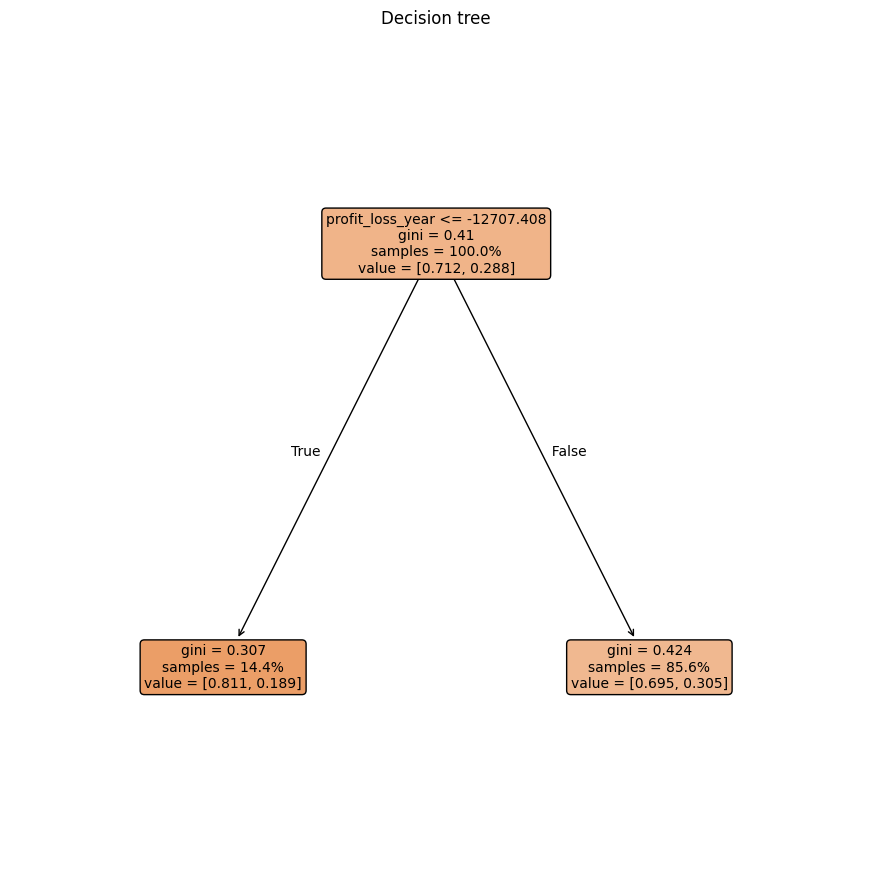

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Select the features you want to visualize
features_for_graph = ["sales_mil", "profit_loss_year", "foreign_management"]

# Create dataset ensuring X and y have matching indices
data_for_graph = data_train[features_for_graph + ['fast_growth']].dropna()
X_graph = data_for_graph[features_for_graph]
y_graph = data_for_graph['fast_growth']

# Fit the decision tree
rf_for_graph = DecisionTreeClassifier(
    ccp_alpha=0.0028, min_samples_leaf=100, max_depth=3, random_state=41
).fit(X_graph, y_graph)

# Plot the tree
plt.figure(figsize=(11, 11))
plot_tree(
    rf_for_graph,
    feature_names=X_graph.columns,
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=10,
)
plt.title("Decision tree")
plt.show()

#### Probability forest

Split by gini, ratio of 1's in each tree, average over trees

In [33]:
grid = {
    "max_features": [5, 6, 7],
    "criterion": ["gini"],
    "min_samples_split": [11, 16],
}

5-fold cross validation

In [34]:
prob_forest = RandomForestClassifier(random_state=42, n_estimators=100, oob_score=True)
prob_forest_grid = GridSearchCV(
    prob_forest,
    grid,
    cv=k,
    refit="roc_auc",
    scoring=["roc_auc", "neg_brier_score"]
)

In [35]:
start_time = time.time()
prob_forest_fit = prob_forest_grid.fit(rfvars_train, y_train)
rf_time = time.time() - start_time
print(f"Random Forest training time: {rf_time:.2f} seconds")

Random Forest training time: 390.74 seconds


Create CV results table

In [36]:
prob_forest_cv_results = pd.DataFrame(
    {
        "max_features": prob_forest_fit.cv_results_["param_max_features"],
        "min_samples_split": prob_forest_fit.cv_results_["param_min_samples_split"],
        "cv_auc": prob_forest_fit.cv_results_["mean_test_roc_auc"],
        "cv_rmse": np.sqrt(
            prob_forest_fit.cv_results_["mean_test_neg_brier_score"] * -1
        ),
    }
)

prob_forest_cv_results

,max_features,min_samples_split,cv_auc,cv_rmse
0,5,11,0.713772,0.426152
1,5,16,0.714042,0.426062
2,6,11,0.713133,0.426408
3,6,16,0.714077,0.426094
4,7,11,0.711198,0.427303
5,7,16,0.713813,0.426356


Obtain optimal parameter values

In [37]:
best_mtry = prob_forest_fit.best_params_["max_features"]
best_min_node_size = prob_forest_fit.best_params_["min_samples_split"]
prob_forest_fit.best_params_

{'criterion': 'gini', 'max_features': 6, 'min_samples_split': 16}

Get average (ie over the folds) RMSE and AUC

In [38]:
prob_forest_best_results = prob_forest_cv_results[
    (prob_forest_cv_results.max_features == best_mtry)
    & (prob_forest_cv_results.min_samples_split == best_min_node_size)
]
prob_forest_best_results_index = prob_forest_best_results.index.values[0]

## 2. Compute AUC for all models

First, for logits

In [39]:
# Fix: store AUC scores separately instead of overwriting logit_models
# (which were fitted with neg_brier_score and are used later for classification)
CV_AUC_folds = dict()
for i, model_vars in enumerate(logit_model_vars):

    model_equation = "fast_growth~" + "+".join(model_vars)
    y_train, X_train = patsy.dmatrices(model_equation, data_train)

    LRCV_auc = LogisticRegressionCV(
        Cs=C_value_logit,
        cv=k,
        refit=True,
        scoring="roc_auc",
        solver="newton-cg",
        tol=1e-5,
        random_state=42,
    )

    logit_auc_model = LRCV_auc.fit(X_train, y_train)

    # Calculate AUC on test for each fold
    CV_AUC_folds["M" + str(i + 1)] = logit_auc_model.scores_[1].ravel()


For LASSO

In [40]:
logLasso_auc = LogisticRegressionCV(
    Cs=C_values,
    penalty="l1",
    cv=k,
    refit=True,
    scoring="roc_auc",
    solver="liblinear",
    random_state=42,
)
logLasso_auc_fitted = logLasso_auc.fit(normalized_logitvars, y_train)

CV_AUC_folds["LASSO"] = logLasso_auc_fitted.scores_[1][
    :, cv_fast_growth_lasso["mean_cv_score"].idxmin()
]

For Random Forest

In [41]:
CV_RMSE_folds["RF"] = np.sqrt(
    pd.DataFrame(prob_forest_fit.cv_results_)
    .filter(like="_test_neg_brier_score")
    .loc[lambda x: x["rank_test_neg_brier_score"] == 1]
    .filter(like="split")
    .values[0]
    * -1
)
CV_AUC_folds["RF"] = (
    pd.DataFrame(prob_forest_fit.cv_results_)
    .filter(like="_test_roc_auc")
    .loc[lambda x: x["rank_test_roc_auc"] == 1]
    .filter(like="split")
    .values[0]
)

### Summary table: all models

In [42]:
model_fits = pd.DataFrame(logit_models, index=["Model fit"]).T

fast_growth = (
    model_fits["Model fit"]
    .apply(lambda x: x.n_features_in_)
    .to_frame(name="Number of Coefficients")
)

fast_growth.loc["LASSO", "Number of Coefficients"] = len(
    [i for i in model_fits.loc["LASSO"].values[0].coef_[0] if i != 0]
)

fast_growth["CV RMSE"] = pd.DataFrame(CV_RMSE_folds).T.mean(axis=1)
fast_growth["CV AUC"] = pd.DataFrame(CV_AUC_folds).T.mean(axis=1)

fast_growth.loc["RF", "Number of Coefficients"] = "n.a."
fast_growth.loc["RF", "CV RMSE"] = prob_forest_best_results["cv_rmse"].values[0]
fast_growth.loc["RF", "CV AUC"] = prob_forest_best_results["cv_auc"].values[0]

In [43]:
print("=" * 80)
print("CROSS-VALIDATION RESULTS: LOGISTIC REGRESSION MODELS")
print("=" * 80)
print("This table shows average performance across 5 CV folds.")
print("CV RMSE = Root Mean Squared Error of predicted probabilities")
print("CV AUC = Area Under ROC Curve (discrimination ability)")
print("Lower RMSE and higher AUC indicate better performance.\n")

fast_growth.round(3)

CROSS-VALIDATION RESULTS: LOGISTIC REGRESSION MODELS
This table shows average performance across 5 CV folds.
CV RMSE = Root Mean Squared Error of predicted probabilities
CV AUC = Area Under ROC Curve (discrimination ability)
Lower RMSE and higher AUC indicate better performance.



,Number of Coefficients,CV RMSE,CV AUC
M1,4.0,0.452,0.564
M2,9.0,0.436,0.672
M3,30.0,0.425,0.716
M4,61.0,0.425,0.718
M5,162.0,0.426,0.715
LASSO,74.0,0.425,0.718
RF,n.a.,0.426,0.714


Foldwise RMSE and AUC

In [44]:
pd.DataFrame(CV_RMSE_folds)

,M1,M2,M3,M4,M5,LASSO,RF
0,0.457426,0.434735,0.421858,0.420875,0.419601,0.420761,0.421169
1,0.447387,0.440091,0.424834,0.424472,0.426997,0.424681,0.425782
2,0.450615,0.436870,0.420574,0.421154,0.422921,0.420904,0.423515
3,0.454907,0.436636,0.427116,0.428222,0.429254,0.426893,0.428253
4,0.448035,0.431464,0.431920,0.431094,0.433281,0.431363,0.431513


In [45]:
pd.DataFrame(CV_AUC_folds)

,M1,M2,M3,M4,M5,LASSO,RF
0,0.560658,0.682839,0.717473,0.721649,0.725283,0.721555,0.723084
1,0.560976,0.664805,0.718988,0.722903,0.714171,0.719260,0.717364
2,0.565763,0.674678,0.728214,0.727191,0.723625,0.728393,0.722109
3,0.563518,0.666181,0.707339,0.706173,0.703838,0.708174,0.698400
4,0.570314,0.673726,0.709208,0.711591,0.708353,0.711415,0.709429


### Pick favorite model

M3, M4, LASSO, and RF are practically the same in terms of CV RMSE (~0.425-0.426). We go with **M4** as our best logit since it achieves the lowest CV RMSE among the logit models while being simpler than M5. Among all three model families (logit, LASSO, RF), we compare CV RMSE and training time to select our favorite for probability prediction.


In [46]:
print("Model performance comparison:")
print(f"  Logit (M4)  - CV RMSE: {fast_growth.loc['M4', 'CV RMSE']:.4f}, Time: {logit_time:.2f}s")
print(f"  LASSO       - CV RMSE: {fast_growth.loc['LASSO', 'CV RMSE']:.4f}, Time: {lasso_time:.2f}s")
print(f"  Random Forest - CV RMSE: {fast_growth.loc['RF', 'CV RMSE']:.4f}, Time: {rf_time:.2f}s")
print()
print("=> For probability prediction, M4 (logit) offers a good balance of performance and simplicity.")

Model performance comparison:
  Logit (M4)  - CV RMSE: 0.4252, Time: 416.53s
  LASSO       - CV RMSE: 0.4249, Time: 191.58s
  Random Forest - CV RMSE: 0.4261, Time: 390.74s

=> For probability prediction, M4 (logit) offers a good balance of performance and simplicity.


### Best logit holdout RMSE

In [47]:
best_logit = logit_models["M4"]
model_equation = "fast_growth~" + "+".join(M4)

# This way X_holdout keeps the original row indices, so we know which rows are retained
y_holdout_patsy, X_holdout = patsy.dmatrices(model_equation, data_holdout, return_type='dataframe')

# Make predictions
pred_values = best_logit.predict_proba(X_holdout)[:, 1]

# Initialize the column as NaN
data_holdout["best_logit_pred_proba"] = np.nan
# Only fill in rows where predictions exist (matching indices)
data_holdout.loc[X_holdout.index, "best_logit_pred_proba"] = pred_values

# Compute RMSE
print("Holdout RMSE for M4:", round(rmse(pred_values, y_holdout_patsy.iloc[:, 0]), 3))

Holdout RMSE for M4: 0.429


In [48]:
# Create clean holdout set for evaluation
cols_to_keep = ["fast_growth", "best_logit_pred_proba"]
data_holdout_clean = data_holdout.dropna(subset=cols_to_keep).copy()

print(f"Original number of rows: {len(data_holdout)}")
print(f"Number of rows remaining for evaluation after cleaning: {len(data_holdout_clean)}")

Original number of rows: 4000
Number of rows remaining for evaluation after cleaning: 3536


### Calibration curve

How well do estimated vs actual event probabilities relate to each other?

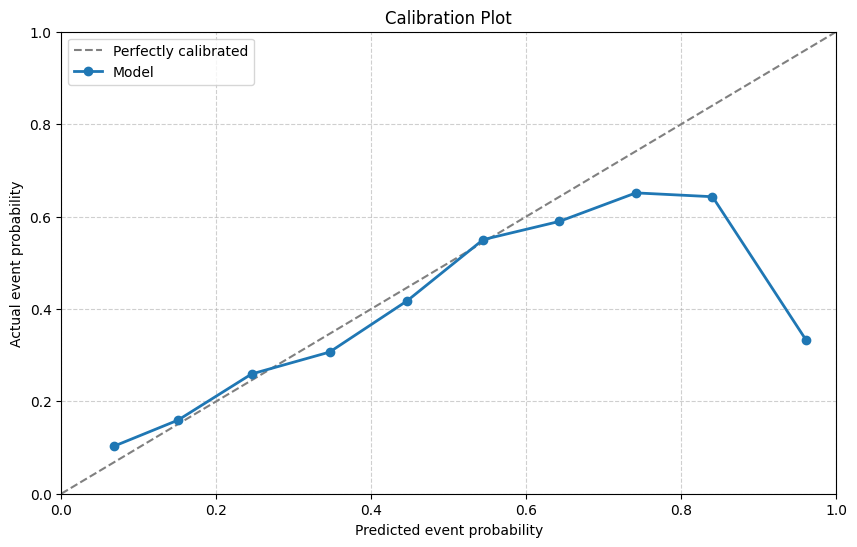

In [49]:
create_calibration_plot(
    data_holdout,
    prob_var="best_logit_pred_proba",
    actual_var="fast_growth",
    y_lab="Actual event probability",
    n_bins=10,
    breaks=None,
)

### ROC curve on holdout

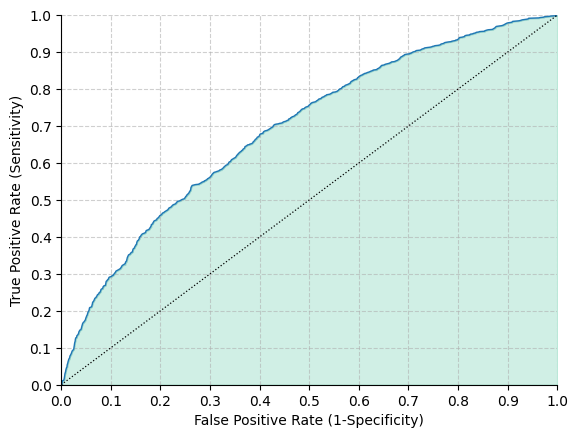

In [50]:
create_roc_plot(data_holdout_clean["fast_growth"], data_holdout_clean["best_logit_pred_proba"])

---
# PART II: Classification

This section applies a business-oriented loss function to convert predicted probabilities into actionable binary classifications.

## 1. Business Problem

We are acting as a **venture capital (VC) screening tool** that identifies firms likely to experience fast growth (≥20% asset growth).
The goal is to flag promising investment targets from a large pool of firms so that analysts can prioritize due diligence efforts,
reducing the cost of missing high-growth opportunities while controlling the cost of wasted analyst time on false leads.

## 2. Loss Function Definition

We define asymmetric costs in dollar terms: a **false positive** (FP) costs **$1** (wasted analyst time reviewing a non-growth firm), 
while a **false negative** (FN) costs **$10** (the opportunity cost of missing a fast-growing firm that could have yielded outsized returns).
The 10:1 ratio reflects that in VC, missing a winner is far more costly than spending time evaluating a dud.
The optimal classification threshold is then chosen to minimize the total expected loss across these asymmetric error costs.

In [51]:
FP = 1
FN = 10
cost = FN / FP  # Loss ratio: 10:1
print(f"Loss function: FN costs {cost}x more than FP")

Loss function: FN costs 10.0x more than FP


In [52]:
# Fix: corrected typo from "prevelance" to "prevalence"
prevalence = y_train.sum() / len(y_train)


## 3. Find optimal thresholds and expected loss for each model

Iterate through all models and CV folds to find the threshold that minimizes expected loss.

In [53]:
best_thresholds_cv = dict()
expected_loss_cv = dict()
fold5_threshold = dict()
fold5_expected_loss = dict()
fold5_all_coords = dict()

for i, model_name in enumerate(logit_models):
    best_thresholds = []
    expected_loss = []

    if model_name != "LASSO":
        y_patsy, X = patsy.dmatrices("fast_growth ~" + "+".join(logit_model_vars[i]), data_train)
        X = pd.DataFrame(X)
        # Fix: use y from patsy (aligned with X after NaN row drops) instead of data_train
        y_aligned = pd.Series(y_patsy.ravel(), name="fast_growth")
        c_index = 0
    else:
        X = normalized_logitvars
        # Fix: use y_train from the LASSO patsy call (already aligned)
        y_aligned = pd.Series(y_train.ravel(), name="fast_growth")
        c_index = best_lambda_i
    fold = 0
    for train_index, test_index in k.split(X):
        X_fold = X.iloc[test_index, :]
        # Fix: use y_aligned (from patsy) with positional indexing instead of data_train
        y_fold = y_aligned.iloc[test_index]
        pred_fold = generate_fold_prediction(
            logit_models[model_name], X_fold, fold, c_index
        )
        false_pos_rate, true_pos_rate, thresholds = roc_curve(y_fold, pred_fold)
        optimal_threshold = sorted(
            list(
                zip(
                    np.abs(
                        true_pos_rate
                        + (1 - prevalence) / (cost * prevalence) * (1 - false_pos_rate)
                    ),
                    thresholds,
                )
            ),
            key=lambda i: i[0],
            reverse=True,
        )[0][1]
        best_thresholds.append(optimal_threshold)
        threshold_prediction = np.where(pred_fold < optimal_threshold, 0, 1)
        tn, fp, fn, tp = confusion_matrix(
            y_fold, threshold_prediction, labels=[0, 1]
        ).ravel()
        curr_exp_loss = (fp * FP + fn * FN) / len(y_fold)
        expected_loss.append(curr_exp_loss)
        fold = fold + 1

    best_thresholds_cv[model_name] = np.mean(best_thresholds)
    expected_loss_cv[model_name] = np.mean(expected_loss)

    # for fold #5
    fold5_threshold[model_name] = optimal_threshold
    fold5_expected_loss[model_name] = curr_exp_loss

    all_coords = pd.DataFrame(
        {
            "false_pos": false_pos_rate * sum(y_fold == 0),
            "true_pos": true_pos_rate * sum(y_fold == 1),
            "false_neg": sum(y_fold == 1) - true_pos_rate * sum(y_fold == 1),
            "true_neg": sum(y_fold == 0) - false_pos_rate * sum(y_fold == 0),
            "pos": sum(y_fold == 1),
            "neg": sum(y_fold == 0),
            "n": len(y_fold),
            "thresholds": thresholds,
        }
    )

    fold5_all_coords[model_name] = all_coords


### Random Forest: loss function optimization over CV folds

In [54]:
best_thresholds_rf = list()
expected_loss_rf = list()
rfvars_train_df = pd.DataFrame(rfvars_train)
# Fix: use y from patsy (aligned with rfvars_train) for RF folds
y_train_rf_aligned = pd.Series(y_train.ravel(), name="fast_growth")

fold = 0
for train_index, test_index in k.split(rfvars_train_df):
    X_fold = rfvars_train_df.iloc[test_index, :]
    # Fix: use aligned y from patsy instead of data_train
    y_fold = y_train_rf_aligned.iloc[test_index]

    X_fold_train = rfvars_train_df.iloc[train_index, :]
    y_fold_train = y_train_rf_aligned.iloc[train_index]

    prob_forest_best = RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        oob_score=True,
        criterion="gini",
        max_features=best_mtry,
        min_samples_split=best_min_node_size,
    )
    prob_forest_best_fold = prob_forest_best.fit(X_fold_train, y_fold_train)
    pred_fold = prob_forest_best_fold.predict_proba(X_fold)[:, 1]

    false_pos_rate, true_pos_rate, threshold = roc_curve(y_fold, pred_fold)
    best_threshold = sorted(
        list(
            zip(
                np.abs(
                    true_pos_rate
                    # Fix: corrected typo from "prevelance" to "prevalence"
                    + (1 - prevalence) / (cost * prevalence) * (1 - false_pos_rate)
                ),
                threshold,
            )
        ),
        key=lambda x: x[0],
        reverse=True,
    )[0][1]
    best_thresholds_rf.append(best_threshold)
    threshold_prediction = np.where(pred_fold < best_threshold, 0, 1)
    tn, fp, fn, tp = confusion_matrix(
        y_fold, threshold_prediction, labels=[0, 1]
    ).ravel()
    curr_exp_loss = (fp * FP + fn * FN) / len(y_fold)
    expected_loss_rf.append(curr_exp_loss)
    fold += 1

fold5_threshold_rf = best_threshold
fold5_expected_loss_rf = curr_exp_loss

all_coords_rf = pd.DataFrame(
    {
        "false_pos": false_pos_rate * sum(y_fold == 0),
        "true_pos": true_pos_rate * sum(y_fold == 1),
        "false_neg": sum(y_fold == 1) - true_pos_rate * sum(y_fold == 1),
        "true_neg": sum(y_fold == 0) - false_pos_rate * sum(y_fold == 0),
        "pos": sum(y_fold == 1),
        "neg": sum(y_fold == 0),
        "n": len(y_fold),
        "thresholds": threshold,
    }
)

expected_loss_cv["RF"] = np.mean(expected_loss_rf)
best_thresholds_cv["RF"] = np.mean(best_thresholds_rf)


### Summary: classification results across all models

In [55]:
fast_growth_with_lossfnc = pd.DataFrame(
    best_thresholds_cv.items(), columns=["Model", "Avg of optimal thresholds"]
)
fast_growth_with_lossfnc["Threshold for Fold5"] = list(fold5_threshold.values()) + [fold5_threshold_rf]
fast_growth_with_lossfnc["Avg expected loss"] = expected_loss_cv.values()
fast_growth_with_lossfnc["Expected loss for Fold5"] = list(fold5_expected_loss.values()) + [fold5_expected_loss_rf]

In [56]:
fast_growth_with_lossfnc

,Model,Avg of optimal thresholds,Threshold for Fold5,Avg expected loss,Expected loss for Fold5
0,M1,0.148891,0.159299,0.709178,0.714911
1,M2,0.119471,0.079742,0.692703,0.710860
2,M3,0.102952,0.077291,0.670074,0.695135
3,M4,0.100732,0.094711,0.669373,0.689534
4,M5,0.088600,0.087660,0.678264,0.687084
5,LASSO,0.115714,0.085703,0.670494,0.690935
6,RF,0.095796,0.072395,0.670424,0.674484


## 4. Select best model

Choose the model with the smallest average expected loss over 5 folds.

In [57]:
best_model_name = fast_growth_with_lossfnc.loc[
    fast_growth_with_lossfnc["Avg expected loss"].idxmin(), "Model"
]
print(f"Best model by average expected loss: {best_model_name}")
print(f"Average expected loss: {expected_loss_cv[best_model_name]:.4f}")

Best model by average expected loss: M4
Average expected loss: 0.6694


### Understanding ROC Curves and AUC

**ROC (Receiver Operating Characteristic) Curve:**
- **X-axis:** False Positive Rate = FP / (FP + TN) — What % of non-growth firms are incorrectly flagged?
- **Y-axis:** True Positive Rate = TP / (TP + FN) — What % of fast-growth firms are correctly caught?
- **Each point:** A different classification threshold (e.g., 0.1, 0.2, 0.5)
- **Diagonal line:** Random guessing (AUC = 0.5)
- **Top-left corner:** Perfect classifier (AUC = 1.0)

**AUC (Area Under the Curve):**
- **Interpretation:** Probability that the model ranks a random fast-growth firm higher than a random non-growth firm
- **Range:** 0.5 (random) to 1.0 (perfect)
- **Our results:** AUC ~0.71-0.72 means the model has good discrimination ability

**Why AUC matters:** 
- Threshold-independent metric — evaluates model across ALL possible thresholds
- Complements RMSE by measuring ranking ability, not just probability calibration

### Loss and ROC plots (Fold 5, M4)

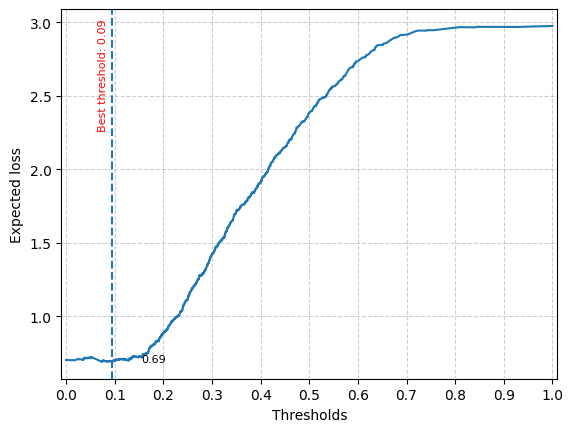

In [58]:
model_to_plot = "M4"
create_loss_plot(
    fold5_all_coords[model_to_plot],
    fold5_threshold[model_to_plot],
    fold5_expected_loss[model_to_plot],
)

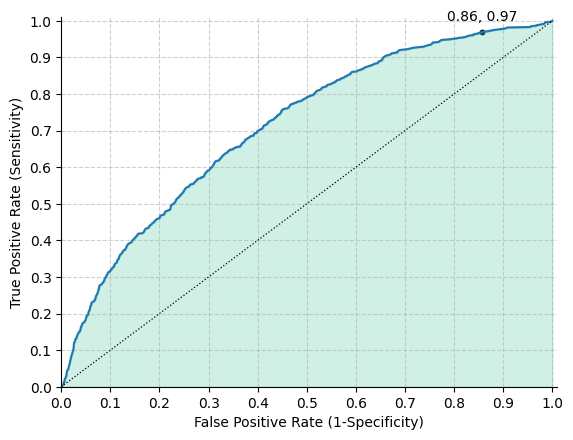

In [59]:
create_roc_plot_with_optimal(
    fold5_all_coords[model_to_plot], fold5_threshold[model_to_plot]
)

### Loss and ROC plots (Fold 5, Random Forest)

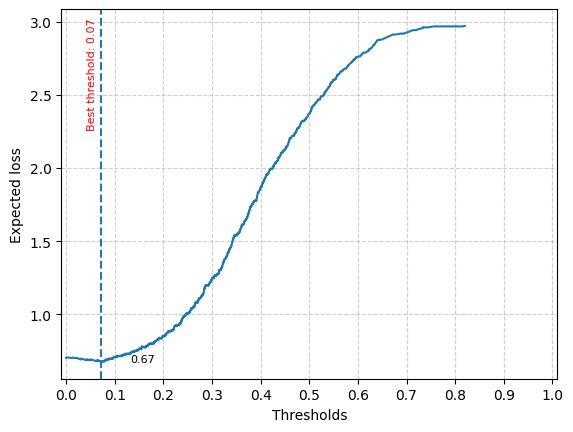

In [60]:
create_loss_plot(all_coords_rf, fold5_threshold_rf, fold5_expected_loss_rf)

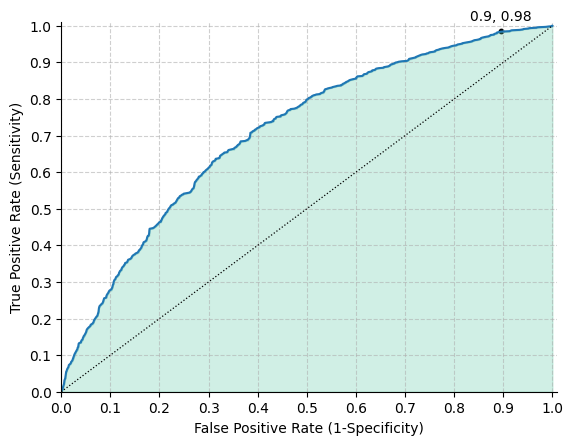

In [61]:
create_roc_plot_with_optimal(all_coords_rf, fold5_threshold_rf)

### Holdout expected loss for M4

In [62]:
best_logit_optimal_treshold = best_thresholds_cv["M4"]

# Fix: filter out NaN predictions before computing holdout loss
holdout_eval = data_holdout.dropna(subset=["best_logit_pred_proba", "fast_growth"]).copy()

# Get expected loss on holdout
holdout_treshold = np.where(
    holdout_eval["best_logit_pred_proba"] < best_logit_optimal_treshold, 0, 1
)
tn, fp, fn, tp = confusion_matrix(
    holdout_eval["fast_growth"], holdout_treshold, labels=[0, 1]
).ravel()
expected_loss_holdout = (fp * FP + fn * FN) / len(holdout_eval["fast_growth"])
print(f"M4 holdout expected loss: {round(expected_loss_holdout, 3)}")


M4 holdout expected loss: 0.733


### Holdout expected loss for Random Forest

In [63]:
prob_forest_fit_best = prob_forest_fit.best_estimator_
rf_predicted_probabilities_holdout = prob_forest_fit_best.predict_proba(rfvars_holdout)[
    :, 1
]
rmse_rf = np.sqrt(mean_squared_error(y_holdout, rf_predicted_probabilities_holdout))
print(f"RF holdout RMSE: {round(rmse_rf, 3)}")

auc_rf = roc_auc_score(y_holdout, rf_predicted_probabilities_holdout)
print(f"RF holdout AUC: {round(auc_rf, 3)}")

holdout_treshold_rf = np.where(
    rf_predicted_probabilities_holdout < best_thresholds_cv["RF"], 0, 1
)
tn, fp, fn, tp = confusion_matrix(y_holdout, holdout_treshold_rf, labels=[0, 1]).ravel()
expected_loss_holdout_rf = (fp * FP + fn * FN) / len(y_holdout)
print(f"RF holdout expected loss: {round(expected_loss_holdout_rf, 3)}")

RF holdout RMSE: 0.429
RF holdout AUC: 0.696
RF holdout expected loss: 0.712


### Final results table

In [64]:
fast_growth["CV treshold"] = best_thresholds_cv
fast_growth["CV expected Loss"] = expected_loss_cv

In [65]:
fast_growth

,Number of Coefficients,CV RMSE,CV AUC,CV treshold,CV expected Loss
M1,4.0,0.451674,0.564246,0.148891,0.709178
M2,9.0,0.435959,0.672446,0.119471,0.692703
M3,30.0,0.425261,0.716244,0.102952,0.670074
M4,61.0,0.425163,0.717902,0.100732,0.669373
M5,162.0,0.426411,0.715054,0.088600,0.678264
LASSO,74.0,0.424920,0.717759,0.115714,0.670494
RF,n.a.,0.426094,0.714077,0.095796,0.670424


---
# PART III: Discussion of Results

## Confusion table on holdout set (best logit model M4)

In [66]:
# Fix: use holdout_eval (NaN-free) for confusion matrix
cm_object3 = confusion_matrix(holdout_eval["fast_growth"], holdout_treshold, labels=[0, 1])
cm3 = pd.DataFrame(
    cm_object3,
    index=["Actual No Fast Growth", "Actual Fast Growth"],
    columns=["Predicted No Fast Growth", "Predicted Fast Growth"],
)
cm3


,Predicted No Fast Growth,Predicted Fast Growth
Actual No Fast Growth,335,2203
Actual Fast Growth,39,959


In [67]:
# Print classification summary
tn, fp, fn, tp = cm_object3.ravel()
total = tn + fp + fn + tp
print(f"Accuracy: {(tn+tp)/total:.2%}")
print(f"Sensitivity (recall): {tp/(tp+fn):.2%}")
print(f"Specificity: {tn/(tn+fp):.2%}")
print(f"Precision: {tp/(tp+fp):.2%}")

Accuracy: 36.60%
Sensitivity (recall): 96.09%
Specificity: 13.20%
Precision: 30.33%


## Discussion of Results

The M4 logit model with optimal threshold (~0.10) achieves the following on the holdout set:

- **Sensitivity (recall): 96.09%** - Catches 959 out of 998 fast-growth firms
- **Precision: 30.33%** - Of 3,162 firms flagged, 959 (30%) are truly fast-growth
- **Specificity: 13.20%** - 335 out of 2,538 non-growth firms correctly rejected
- **Accuracy: 36.60%** - Low overall accuracy due to low threshold

- **Expected Loss:** $0.733 per firm
  - False Positive cost: 2,203 x $1 = $2,203
  - False Negative cost: 39 x $10 = $390
  - Total: $2,593 for 3,536 evaluated firms

### Key Insights

1. **Low Threshold (~0.10):** The 10:1 cost asymmetry (FN costs 10x more than FP) pushes the optimal threshold well below 0.5, so the model flags any firm with a predicted fast-growth probability above ~10%.

2. **High Recall:** Catching 96% of fast-growth firms (missing only 39 out of 998) reflects the model's successful focus on minimizing costly false negatives.

3. **High False Positive Rate:** Flagging 87% of non-growth firms is the deliberate trade-off for high recall. This is rational given FP costs only $1 while FN costs $10.

4. **Low Precision Is Expected:** Only 30% of flagged firms are truly fast-growth, but this is consistent with the loss function. With a ~29% base rate and 10:1 cost ratio, the threshold naturally shifts far below 0.5.

5. **Holdout vs. Baseline:** The M4 holdout expected loss ($0.733) is slightly higher than the naive strategy of flagging all firms (~$0.718), suggesting some overfitting of the threshold or distributional shift in the holdout set. In contrast, the Random Forest achieves a holdout expected loss of $0.712, outperforming both M4 and the baseline.

### Comparison: M4 vs Random Forest on Holdout

- **M4 Logit Expected Loss:** $0.733 per firm
- **Random Forest Expected Loss:** $0.712 per firm
- **RF advantage:** Saves $0.021 per firm (2.9% reduction)

Despite having nearly identical CV RMSE (~0.425 vs 0.426), the Random Forest achieves a better holdout expected loss. This suggests that RF's threshold calibration generalizes better to unseen data in this case, likely because RF's ensemble structure provides more robust probability estimates near the classification boundary.


## Actionability and Limitations

The predictions are actionable as a **first-pass screening tool**: analysts can prioritize flagged firms for deeper due diligence rather than treating the model's output as a final investment decision. With the optimal threshold (~0.10), the model flags roughly 89% of firms, filtering out only the least likely candidates for fast growth. Key limitations include that fast growth is defined on a single historical year (2012-2013), the model cannot capture macroeconomic shocks or industry disruptions, and the 10:1 loss asymmetry inherently favors high recall at the expense of precision. The Random Forest model shows better holdout performance than the logit, suggesting it may be the preferred choice for deployment. External validation on out-of-sample time periods would strengthen confidence before deployment.


---
# Tasks 2: Industry Analysis (Optional Enhancement)

The dataset has two broad industry groups based on `ind2_cat`:
- **Manufacturing**: `ind2_cat` in {20, 30} (lower industry codes)
- **Services**: `ind2_cat` in {40, 60} (repair, accommodation, food, and other services)

We use the same loss function (FP=\$1, FN=\$10) but carry out the exercise separately for each group.

In [68]:
# Define industry groups
data_train["industry_group"] = np.where(
    data_train["ind2_cat"].isin([20, 30]), "Manufacturing",
    np.where(data_train["ind2_cat"].isin([40, 60]), "Services", "Other")
)
data_holdout["industry_group"] = np.where(
    data_holdout["ind2_cat"].isin([20, 30]), "Manufacturing",
    np.where(data_holdout["ind2_cat"].isin([40, 60]), "Services", "Other")
)

print("Training set industry distribution:")
print(data_train["industry_group"].value_counts())
print(f"\nHoldout set industry distribution:")
print(data_holdout["industry_group"].value_counts())

Training set industry distribution:
industry_group
Other            15481
Services           340
Manufacturing      175
Name: count, dtype: int64

Holdout set industry distribution:
industry_group
Other            3874
Services           88
Manufacturing      38
Name: count, dtype: int64


In [69]:
# Variables for industry-specific models (remove ind2_cat since we split by it)
# Use M4-style logit vars without industry interactions
industry_logit_vars = (
    ["sales_mil_log"]
    + engvar
    + engvar2
    + engvar3
    + d1
    + ["gender_m", "foreign_management", "age", "age2", "new", "m_region_loc"]
    + growth_features
    + qualityvars
)

# RF vars without ind2_cat
industry_rf_vars = (
    ["sales_mil", "d1_sales_mil_log_mod"]
    + rawvars
    + ["gender_m", "foreign_management", "age", "age2", "new", "m_region_loc"]
    + growth_features
    + qualityvars
)

In [70]:
industry_results = {}

for group in ["Manufacturing", "Services"]:
    print(f"\n{'='*60}")
    print(f"  INDUSTRY: {group}")
    print(f"{'='*60}")

    train_sub = data_train[data_train["industry_group"] == group].copy()
    holdout_sub = data_holdout[data_holdout["industry_group"] == group].copy()

    print(f"Train size: {len(train_sub)}, Fast growth rate: {train_sub['fast_growth'].mean():.2%}")
    print(f"Holdout size: {len(holdout_sub)}, Fast growth rate: {holdout_sub['fast_growth'].mean():.2%}")

    k_ind = KFold(n_splits=5, shuffle=True, random_state=42)

    # --- Logit (M4-style) ---
    model_eq = "fast_growth~" + "+".join(industry_logit_vars)
    y_tr, X_tr = patsy.dmatrices(model_eq, train_sub)

    logit_cv = LogisticRegressionCV(
        Cs=[1e20], cv=k_ind, refit=True,
        scoring="neg_brier_score", solver="newton-cg", tol=1e-7, random_state=42,
    )
    logit_fit = logit_cv.fit(X_tr, y_tr)
    logit_rmse = np.sqrt(-1 * logit_fit.scores_[1].ravel()).mean()

    # --- Random Forest ---
    y_tr_rf, X_tr_rf = patsy.dmatrices("fast_growth~" + "+".join(industry_rf_vars), train_sub)

    rf_cv = GridSearchCV(
        RandomForestClassifier(random_state=42, n_estimators=500, oob_score=True),
        {"max_features": [5, 6, 7], "criterion": ["gini"], "min_samples_split": [11, 16]},
        cv=k_ind, refit="roc_auc", scoring=["roc_auc", "neg_brier_score"],
    )
    rf_fit = rf_cv.fit(X_tr_rf, y_tr)
    rf_rmse = np.sqrt(-1 * rf_fit.cv_results_["mean_test_neg_brier_score"][rf_fit.best_index_])

    # --- Loss function optimization for both models ---
    prev = y_tr.sum() / len(y_tr)

    # Logit loss
    logit_losses = []
    logit_thresholds = []
    X_tr_df = pd.DataFrame(X_tr)
    # Fix: use y from patsy (aligned with X) instead of train_sub
    y_tr_aligned = pd.Series(y_tr.ravel(), name="fast_growth")
    fold_idx = 0
    for train_idx, test_idx in k_ind.split(X_tr_df):
        X_fold = X_tr_df.iloc[test_idx]
        y_fold = y_tr_aligned.iloc[test_idx]
        # Fix: use correct fold index instead of hardcoded 0
        pred = generate_fold_prediction(logit_fit, X_fold, fold_idx, 0)
        fpr_f, tpr_f, thr_f = roc_curve(y_fold, pred)
        opt_thr = sorted(
            zip(np.abs(tpr_f + (1-prev)/(cost*prev)*(1-fpr_f)), thr_f),
            key=lambda x: x[0], reverse=True
        )[0][1]
        logit_thresholds.append(opt_thr)
        pred_class = np.where(pred < opt_thr, 0, 1)
        tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_fold, pred_class, labels=[0,1]).ravel()
        logit_losses.append((fp_f*FP + fn_f*FN)/len(y_fold))
        fold_idx += 1

    # RF loss
    rf_losses = []
    rf_thresholds = []
    X_tr_rf_df = pd.DataFrame(X_tr_rf)
    y_tr_rf_aligned = pd.Series(y_tr_rf.ravel(), name="fast_growth")
    best_mtry_ind = rf_fit.best_params_["max_features"]
    best_mss_ind = rf_fit.best_params_["min_samples_split"]
    for train_idx, test_idx in k_ind.split(X_tr_rf_df):
        X_fold = X_tr_rf_df.iloc[test_idx]
        y_fold = y_tr_rf_aligned.iloc[test_idx]
        X_fold_tr = X_tr_rf_df.iloc[train_idx]
        y_fold_tr = y_tr_rf_aligned.iloc[train_idx]
        rf_fold = RandomForestClassifier(
            random_state=42, n_estimators=500, oob_score=True,
            max_features=best_mtry_ind, min_samples_split=best_mss_ind,
        ).fit(X_fold_tr, y_fold_tr)
        pred = rf_fold.predict_proba(X_fold)[:, 1]
        fpr_f, tpr_f, thr_f = roc_curve(y_fold, pred)
        opt_thr = sorted(
            zip(np.abs(tpr_f + (1-prev)/(cost*prev)*(1-fpr_f)), thr_f),
            key=lambda x: x[0], reverse=True
        )[0][1]
        rf_thresholds.append(opt_thr)
        pred_class = np.where(pred < opt_thr, 0, 1)
        tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_fold, pred_class, labels=[0,1]).ravel()
        rf_losses.append((fp_f*FP + fn_f*FN)/len(y_fold))

    # Store results
    industry_results[group] = {
        "Logit CV RMSE": round(logit_rmse, 4),
        "Logit Avg Expected Loss": round(np.mean(logit_losses), 4),
        "Logit Avg Threshold": round(np.mean(logit_thresholds), 4),
        "RF CV RMSE": round(rf_rmse, 4),
        "RF Avg Expected Loss": round(np.mean(rf_losses), 4),
        "RF Avg Threshold": round(np.mean(rf_thresholds), 4),
        "Recommended Model": "Logit" if np.mean(logit_losses) <= np.mean(rf_losses) else "RF",
    }

    print(f"\n  Logit - CV RMSE: {logit_rmse:.4f}, Avg Expected Loss: {np.mean(logit_losses):.4f}")
    print(f"  RF    - CV RMSE: {rf_rmse:.4f}, Avg Expected Loss: {np.mean(rf_losses):.4f}")
    print(f"  => Recommended: {industry_results[group]['Recommended Model']}")



  INDUSTRY: Manufacturing
Train size: 175, Fast growth rate: 26.86%
Holdout size: 38, Fast growth rate: 42.11%

  Logit - CV RMSE: 0.5434, Avg Expected Loss: 0.6312
  RF    - CV RMSE: 0.4427, Avg Expected Loss: 0.6115
  => Recommended: RF

  INDUSTRY: Services
Train size: 340, Fast growth rate: 27.65%
Holdout size: 88, Fast growth rate: 27.27%

  Logit - CV RMSE: 0.4782, Avg Expected Loss: 0.6919
  RF    - CV RMSE: 0.4227, Avg Expected Loss: 0.5689
  => Recommended: RF


In [71]:
# Compare across industries
industry_comparison = pd.DataFrame(industry_results).T
industry_comparison

,Logit CV RMSE,Logit Avg Expected Loss,Logit Avg Threshold,RF CV RMSE,RF Avg Expected Loss,RF Avg Threshold,Recommended Model
Manufacturing,0.5434,0.6312,0.0056,0.4427,0.6115,0.1359,RF
Services,0.4782,0.6919,0.0198,0.4227,0.5689,0.1367,RF


## Industry comparison

Industry-specific modeling reveals important patterns in how model performance varies across sectors.

### Key Findings

#### 1. Sample Size Constraints

**Manufacturing:**
- Training: 175 firms (26.86% fast growth rate)
- Holdout: 38 firms (42.11% fast growth rate)

**Services:**
- Training: 340 firms (27.65% fast growth rate)
- Holdout: 88 firms (27.27% fast growth rate)

Industry-specific models should be interpreted cautiously due to limited data, especially for manufacturing.

#### 2. Random Forest Outperforms Logit on Both Metrics

In both industries, Random Forest achieves better performance on both probability prediction (RMSE) and business outcomes (expected loss):

| Industry | Model | CV RMSE | Expected Loss | Winner |
|----------|-------|---------|---------------|--------|
| Manufacturing | Logit | 0.5434 | 0.6312 | |
| | RF | 0.4427 | 0.6115 | RF |
| Services | Logit | 0.4782 | 0.6919 | |
| | RF | 0.4227 | 0.5689 | RF |

This is a consistent result: RF dominates logit in both statistical accuracy and business value in the industry-specific models.

#### 3. Threshold Calibration Differences

**Manufacturing:**
- Logit threshold: 0.0056 (flags firms with >0.6% predicted probability)
- RF threshold: 0.1359 (flags firms with >13.6% predicted probability)

**Services:**
- Logit threshold: 0.0198 (flags firms with >2.0% predicted probability)
- RF threshold: 0.1367 (flags firms with >13.7% predicted probability)

Logit produces extremely low thresholds that effectively flag nearly all firms, while RF finds more discriminative thresholds. Despite RF's higher thresholds allowing more false negatives, RF's superior probability predictions more than compensate, resulting in lower overall expected loss.

#### 4. Industry Heterogeneity

**Fast Growth Rates:**
- Manufacturing: 26.86% (training) vs 42.11% (holdout) - **Large discrepancy suggests sampling variation**
- Services: 27.65% (training) vs 27.27% (holdout) - Stable across samples
- Overall: 28.86% base rate

**Model Performance Variation:**
- Manufacturing has much worse RMSE for logit (0.5434) compared to services (0.4782)
- Suggests manufacturing growth is harder to predict from financial statements using a linear model
- RF's ability to capture non-linear patterns is especially valuable in manufacturing

### Conclusion

In the industry-specific analysis, Random Forest consistently outperforms logit on both RMSE and expected loss. This contrasts with the pooled model results where M4 and RF perform similarly on CV metrics. The likely explanation is that with small industry-specific samples (175-340 firms), logit's many parameters (from the M4-style specification) overfit, while RF's built-in regularization (ensemble averaging, min_samples_split) provides better generalization.

However, the small sample sizes mean these results should be viewed as exploratory analysis rather than reliable production models. The overall pooled model with ~16,000 observations provides more stable predictions and should be preferred for deployment, with industry effects incorporated as features within the unified model.
